# 01 — Data: exploration, split, windows and normalisation

This notebook turns the raw NGSIM I-80 trajectories into the labelled, normalised windows used by all the other notebooks (Sec. 2 and Appendix A of the report).

**Input:** `trajectories-0400-0415.csv` (NGSIM I-80, 4:00–4:15 p.m.; not included in the repository).

**Outputs:**
- `dataset_finestre.npz` — training, validation and test windows (already normalised), the straddling windows of the test set, and the normalisation constants;
- `fig_aligned_trajectories.pdf` (Fig. 2) and `fig_relpos.pdf` (Fig. 7).

**Naming.** Identifiers and printed messages are in Italian. The most frequent ones: `cambi_puliti` = "clean" lane changes (between highway lanes 1–6), `veicoli` = vehicles, `finestre` = windows, `a cavallo` / `cav` = straddling (a window that contains a lane crossing), `costruisci_finestre` = build windows, `rientro` = return (approach to the lane boundary without crossing it).

## 1. Loading and first look at the data

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the raw trajectories. One row = one vehicle at one frame (10 Hz).
df = pd.read_csv("trajectories-0400-0415.csv")

# Number of rows and columns
print("Dimensioni:", df.shape)

# First rows
df.head()

Dimensioni: (1048575, 18)


,Vehicle_ID,Frame_ID,Total_Frames,Global_Time,Local_X,Local_Y,Global_X,Global_Y,v_Length,v_Width,v_Class,v_Vel,v_Acc,Lane_ID,Preceding,Following,Space_Headway,Time_Headway
0,1,12,884,1113433136100,16.884,48.213,6042842.116,2133117.662,14.3,6.4,2,12.5,0.0,2,0,0,0.0,0.0
1,1,13,884,1113433136200,16.938,49.463,6042842.012,2133118.909,14.3,6.4,2,12.5,0.0,2,0,0,0.0,0.0
2,1,14,884,1113433136300,16.991,50.712,6042841.908,2133120.155,14.3,6.4,2,12.5,0.0,2,0,0,0.0,0.0
3,1,15,884,1113433136400,17.045,51.963,6042841.805,2133121.402,14.3,6.4,2,12.5,0.0,2,0,0,0.0,0.0
4,1,16,884,1113433136500,17.098,53.213,6042841.701,2133122.649,14.3,6.4,2,12.5,0.0,2,0,0,0.0,0.0


In [5]:
# Number of distinct vehicles
print("Numero di veicoli:", df["Vehicle_ID"].nunique())

# Values taken by the lane index and number of rows for each of them
# (1 = leftmost lane, 6 = rightmost lane, 7 = on-ramp)
print("\nDistribuzione delle corsie:")
print(df["Lane_ID"].value_counts().sort_index())

# Number of frames recorded per vehicle
print("\nFrame per veicolo (statistiche):")
print(df.groupby("Vehicle_ID").size().describe())

Numero di veicoli: 1725

Distribuzione delle corsie:
Lane_ID
1     81809
2    204811
3    170492
4    203447
5    179757
6    184156
7     24103
Name: count, dtype: int64

Frame per veicolo (statistiche):
count    1725.000000
mean      607.869565
std       195.725691
min       203.000000
25%       489.000000
50%       633.000000
75%       748.000000
max      1168.000000
dtype: float64


### Completeness of the file

Our copy of the file contains only its first 1,048,575 rows. This cell checks what was lost: it compares, for every vehicle, the number of rows actually present with the number of frames declared in `Total_Frames`. Only the last vehicle is incomplete.

In [24]:
print("Righe:", len(df))
print("Vehicle_ID max:", df["Vehicle_ID"].max())
print("Frame_ID min-max:", df["Frame_ID"].min(), "-", df["Frame_ID"].max())

# Rows actually present vs frames declared for each vehicle
righe_per_veicolo = df.groupby("Vehicle_ID").size()
frame_dichiarati = df.groupby("Vehicle_ID")["Total_Frames"].first()
incompleti = righe_per_veicolo[righe_per_veicolo < frame_dichiarati]
print("Veicoli con traiettoria incompleta:", len(incompleti))
print(incompleti.head())

Righe: 1048575
Vehicle_ID max: 2911
Frame_ID min-max: 4 - 8741
Veicoli con traiettoria incompleta: 1
Vehicle_ID
2911    697
dtype: int64


## 2. Exploratory analysis of lane changes

A lane-change event is a change of `Lane_ID` between two consecutive frames of the same vehicle.

In [6]:
# Sort by vehicle and by time: required to compare consecutive frames
df = df.sort_values(["Vehicle_ID", "Frame_ID"]).reset_index(drop=True)

# Lane of the PREVIOUS frame of the SAME vehicle.
# groupby("Vehicle_ID") prevents comparing the last frame of a vehicle with the first of the next one.
df["Lane_prev"] = df.groupby("Vehicle_ID")["Lane_ID"].shift(1)

# A lane change occurs when the current lane differs from the previous one
# (the first row of each vehicle, where Lane_prev is empty, is excluded)
df["lane_change"] = (df["Lane_ID"] != df["Lane_prev"]) & (df["Lane_prev"].notna())

# Total number of lane-change events
print("Numero totale di eventi di cambio corsia:", df["lane_change"].sum())

# Number of vehicles with at least one lane change
veicoli_con_cambio = df.groupby("Vehicle_ID")["lane_change"].any().sum()
print("Veicoli che cambiano corsia almeno una volta:", veicoli_con_cambio, "su 1725")

# Fraction of frames that are a lane change (a first idea of the class imbalance)
print("Percentuale di frame che sono un cambio corsia: "
      f"{100 * df['lane_change'].mean():.3f}%")

Numero totale di eventi di cambio corsia: 887
Veicoli che cambiano corsia almeno una volta: 572 su 1725
Percentuale di frame che sono un cambio corsia: 0.085%


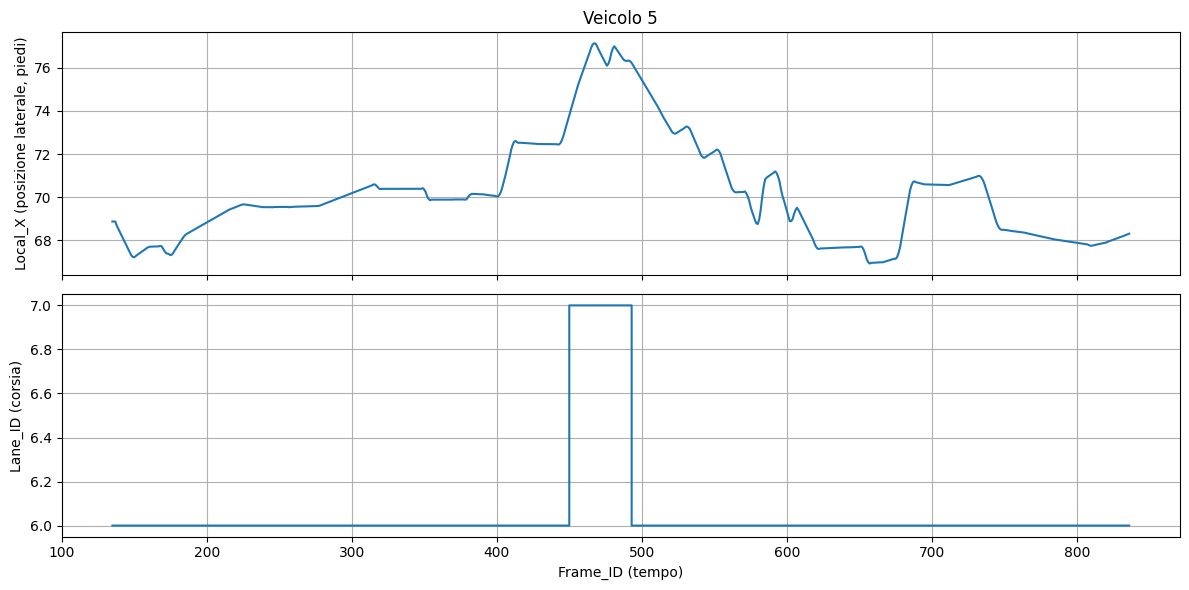

In [7]:
# Trajectory of one vehicle that changes lane at least once (the first one in the file)
veicoli_cambio = df.groupby("Vehicle_ID")["lane_change"].any()
primo_id = veicoli_cambio[veicoli_cambio].index[0]

# Its complete trajectory
v = df[df["Vehicle_ID"] == primo_id]

# Lateral position (top) and lane index (bottom) over time
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax1.plot(v["Frame_ID"], v["Local_X"])
ax1.set_ylabel("Local_X (posizione laterale, piedi)")
ax1.set_title(f"Veicolo {primo_id}")
ax1.grid(True)

ax2.plot(v["Frame_ID"], v["Lane_ID"], drawstyle="steps-post")
ax2.set_ylabel("Lane_ID (corsia)")
ax2.set_xlabel("Frame_ID (tempo)")
ax2.grid(True)

plt.tight_layout()
plt.show()

Veicolo scelto: 50


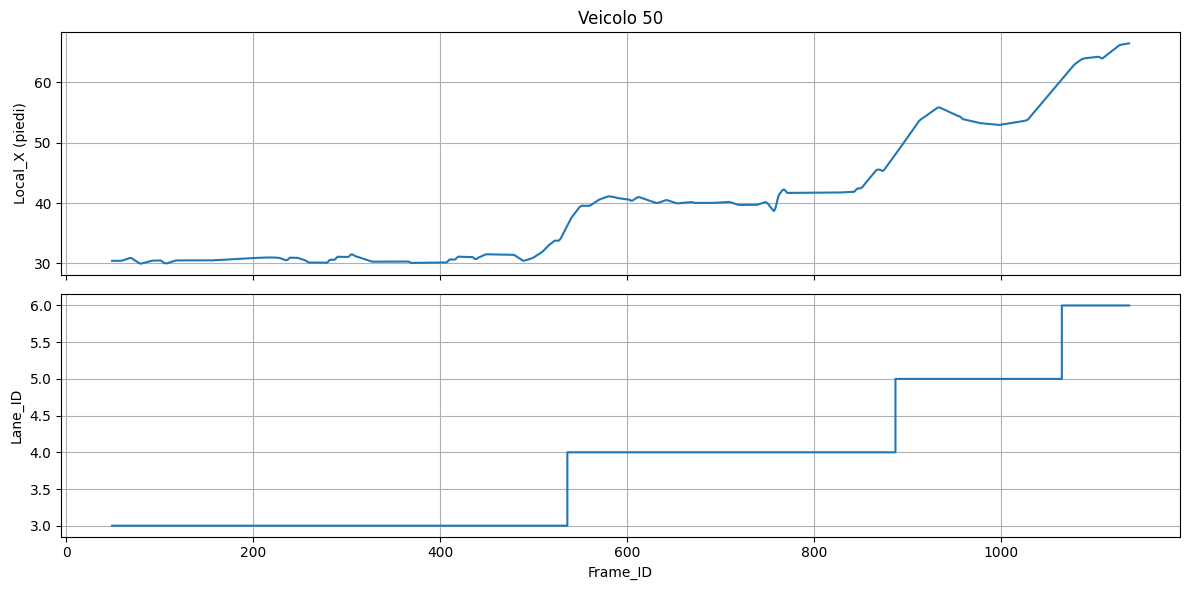

In [8]:
# "Clean" lane changes: both the lane of departure and the lane of arrival are highway
# lanes (1-6). Events involving the on-ramp (lane 7) are merges and are left out.
cambi_puliti = df[
    df["lane_change"]
    & df["Lane_ID"].between(1, 6)
    & df["Lane_prev"].between(1, 6)
]

# Plot the trajectory of one vehicle with a clean lane change (an arbitrary one: index 10)
id_pulito = cambi_puliti["Vehicle_ID"].iloc[10]
print("Veicolo scelto:", id_pulito)

v = df[df["Vehicle_ID"] == id_pulito]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax1.plot(v["Frame_ID"], v["Local_X"])
ax1.set_ylabel("Local_X (piedi)")
ax1.set_title(f"Veicolo {id_pulito}")
ax1.grid(True)
ax2.plot(v["Frame_ID"], v["Lane_ID"], drawstyle="steps-post")
ax2.set_ylabel("Lane_ID")
ax2.set_xlabel("Frame_ID")
ax2.grid(True)
plt.tight_layout()
plt.show()

### How early does the lateral signal appear? (Table 1)

For every clean lane change with at least 4 s of history, the position 4 s before the crossing is taken as reference. We then measure how far the vehicle has moved from it, in the direction of the manoeuvre, at 3, 2, 1 and 0 s before the crossing. The direction is the sign of the net displacement over the 4 s.

In [9]:
righe = []
for _, e in cambi_puliti.iterrows():
    # The 41 frames from 4 s before the crossing to the crossing itself
    v = df[(df["Vehicle_ID"] == e["Vehicle_ID"]) &
           (df["Frame_ID"] >= e["Frame_ID"] - 40) & (df["Frame_ID"] <= e["Frame_ID"])]
    if len(v) < 41:                      # keep only lane changes with 4 complete seconds of history
        continue
    x = v["Local_X"].values              # x[0] = 4 s before the crossing, x[40] = crossing instant
    verso = np.sign(x[-1] - x[0])        # +1 towards the right, -1 towards the left
    d = verso * (x - x[0])               # displacement in the direction of the manoeuvre
    righe.append({"-3 s": d[10], "-2 s": d[20], "-1 s": d[30], "0 s": d[40]})

spost = pd.DataFrame(righe)
print(f"Cambi con 4 s completi di storia: {len(spost)}")
print(spost.describe(percentiles=[0.25, 0.5, 0.75]).round(1))
# Fraction of lane changes whose displacement exceeds 2 ft, the noise level of Local_X
print("\nFrazione di cambi con spostamento > 2 ft (oltre il rumore):")
print((spost > 2).mean().round(2))

Cambi con 4 s completi di storia: 634
        -3 s   -2 s   -1 s    0 s
count  634.0  634.0  634.0  634.0
mean     0.6    1.6    3.3    6.0
std      1.0    1.8    2.5    2.9
min     -1.5   -9.1   -4.0    0.1
25%     -0.0    0.4    2.0    4.3
50%      0.4    1.3    2.9    5.5
75%      1.0    2.3    4.2    6.9
max      5.3   11.8   19.3   26.5

Frazione di cambi con spostamento > 2 ft (oltre il rumore):
-3 s    0.08
-2 s    0.31
-1 s    0.75
0 s     0.98
dtype: float64


### Nine individual lane changes

A quick visual check of nine randomly chosen clean lane changes, each shown from 6 s before to 6 s after the crossing (red dashed line).

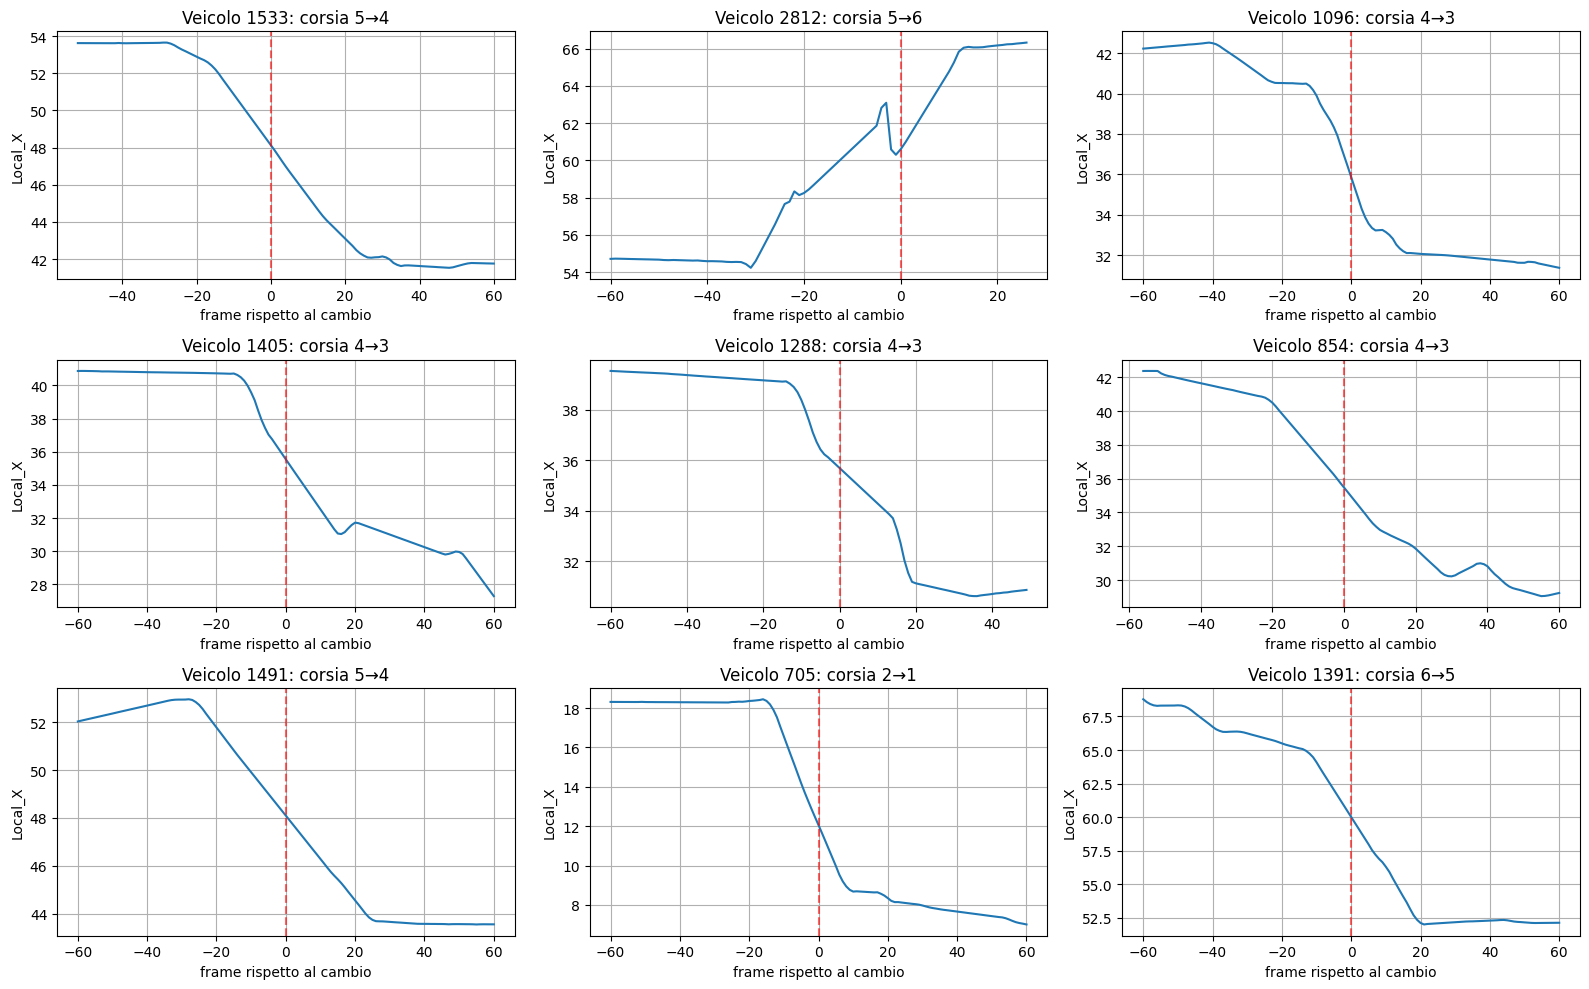

In [10]:
# All clean lane changes (between lanes 1-6, no on-ramp)
cambi_puliti = df[
    df["lane_change"]
    & df["Lane_ID"].between(1, 6)
    & df["Lane_prev"].between(1, 6)
].copy()

# Nine lane changes chosen at random (fixed seed for reproducibility)
np.random.seed(42)
campione = cambi_puliti.sample(9)

fig, axes = plt.subplots(3, 3, figsize=(16, 10))

for ax, (_, evento) in zip(axes.flat, campione.iterrows()):
    vid = evento["Vehicle_ID"]
    frame_cambio = evento["Frame_ID"]

    # Trajectory of the vehicle within +/- 60 frames (6 s) of the crossing
    v = df[df["Vehicle_ID"] == vid]
    v = v[(v["Frame_ID"] >= frame_cambio - 60) & (v["Frame_ID"] <= frame_cambio + 60)]

    # Time relative to the crossing (0 = crossing instant)
    t_rel = v["Frame_ID"] - frame_cambio

    ax.plot(t_rel, v["Local_X"])
    ax.axvline(0, color="red", linestyle="--", alpha=0.6)  # crossing instant
    ax.set_title(f"Veicolo {vid}: corsia {int(evento['Lane_prev'])}→{int(evento['Lane_ID'])}")
    ax.set_xlabel("frame rispetto al cambio")
    ax.set_ylabel("Local_X")
    ax.grid(True)

plt.tight_layout()
plt.show()

### Aligned trajectories (Fig. 2)

All clean lane changes with at least 6 s of data on both sides are aligned on the crossing instant and expressed as lateral displacement in the direction of the change. The figure shows nine random examples, the median and the interquartile range.

Cambi con 6 s completi prima e dopo: 532


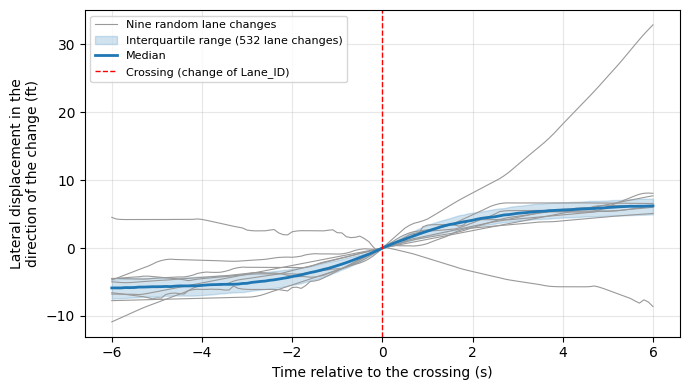

In [12]:
MEZZA = 60                                   # 60 frames = 6 s before and after the crossing
t = np.arange(-MEZZA, MEZZA + 1) / 10        # time axis in seconds

def traiettoria_allineata(evento):
    """Lateral displacement around one lane change, positive in the direction of the change
    and equal to 0 at the crossing. Returns None if 6 s on both sides are not available."""
    v = df[(df["Vehicle_ID"] == evento["Vehicle_ID"]) &
           (df["Frame_ID"] >= evento["Frame_ID"] - MEZZA) &
           (df["Frame_ID"] <= evento["Frame_ID"] + MEZZA)]
    if len(v) < 2 * MEZZA + 1:               # 6 complete seconds are needed before and after
        return None
    x = v["Local_X"].values
    verso = np.sign(evento["Lane_ID"] - evento["Lane_prev"])   # +1 right, -1 left
    return verso * (x - x[MEZZA])            # 0 at the crossing instant

tutte = [traiettoria_allineata(e) for _, e in cambi_puliti.iterrows()]
tutte = np.array([d for d in tutte if d is not None])
print("Cambi con 6 s completi prima e dopo:", len(tutte))

# Nine random examples, and median / quartiles over all the aligned lane changes
rng = np.random.default_rng(42)
esempi = tutte[rng.choice(len(tutte), 9, replace=False)]
q25, q50, q75 = np.percentile(tutte, [25, 50, 75], axis=0)

fig, ax = plt.subplots(figsize=(7, 4))
for k, d in enumerate(esempi):
    ax.plot(t, d, color="0.6", lw=0.8,
            label="Nine random lane changes" if k == 0 else None)
ax.fill_between(t, q25, q75, color="tab:blue", alpha=0.2,
                label=f"Interquartile range ({len(tutte)} lane changes)")
ax.plot(t, q50, color="tab:blue", lw=2, label="Median")
ax.axvline(0, color="red", ls="--", lw=1, label="Crossing (change of Lane_ID)")
ax.set_xlabel("Time relative to the crossing (s)")
ax.set_ylabel("Lateral displacement in the\ndirection of the change (ft)")
ax.grid(alpha=0.3)
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.savefig("fig_aligned_trajectories.pdf", bbox_inches="tight")
plt.show()

## 3. Building the dataset

From here on the notebook builds the dataset. The file is reloaded and the lane-change columns are recomputed, so that this part starts from a clean table.

In [14]:
df = pd.read_csv("trajectories-0400-0415.csv")
df = df.sort_values(["Vehicle_ID", "Frame_ID"]).reset_index(drop=True)
df["Lane_prev"] = df.groupby("Vehicle_ID")["Lane_ID"].shift(1)
df["lane_change"] = (df["Lane_ID"] != df["Lane_prev"]) & (df["Lane_prev"].notna())
print("Dati pronti:", df.shape)

Dati pronti: (1048575, 20)


### Split by vehicle (70 / 15 / 15 %)

Consecutive windows of the same vehicle are nearly identical, so the split is made on vehicles, not on windows: every vehicle belongs to exactly one of the three sets.

In [15]:
# All distinct vehicles
veicoli = df["Vehicle_ID"].unique()
print("Veicoli totali:", len(veicoli))

# Shuffle the vehicles reproducibly (fixed seed)
rng = np.random.default_rng(42)
veicoli_mescolati = rng.permutation(veicoli)

# 70% / 15% / 15% split
n = len(veicoli_mescolati)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)

veicoli_train = set(veicoli_mescolati[:n_train])
veicoli_val   = set(veicoli_mescolati[n_train:n_train + n_val])
veicoli_test  = set(veicoli_mescolati[n_train + n_val:])

print(f"Veicoli train: {len(veicoli_train)}")
print(f"Veicoli val:   {len(veicoli_val)}")
print(f"Veicoli test:  {len(veicoli_test)}")

Veicoli totali: 1725
Veicoli train: 1207
Veicoli val:   258
Veicoli test:  260


In [16]:
# For each set: number of vehicles, of frames and of clean lane changes
# (between lanes 1-6, on-ramp excluded)
def statistiche_gruppo(nome, insieme_veicoli):
    sub = df[df["Vehicle_ID"].isin(insieme_veicoli)]
    # clean lane changes: departure and arrival lanes both in 1-6
    cambi_puliti = sub[
        sub["lane_change"]
        & sub["Lane_ID"].between(1, 6)
        & sub["Lane_prev"].between(1, 6)
    ]
    print(f"{nome:6s} | veicoli: {sub['Vehicle_ID'].nunique():5d} | "
          f"frame: {len(sub):7d} | cambi puliti: {len(cambi_puliti):4d}")

print("Gruppo | veicoli        | frame         | cambi corsia puliti")
statistiche_gruppo("TRAIN", veicoli_train)
statistiche_gruppo("VAL",   veicoli_val)
statistiche_gruppo("TEST",  veicoli_test)

Gruppo | veicoli        | frame         | cambi corsia puliti
TRAIN  | veicoli:  1207 | frame:  730090 | cambi puliti:  486
VAL    | veicoli:   258 | frame:  161731 | cambi puliti:  110
TEST   | veicoli:   260 | frame:  156754 | cambi puliti:   96


### Features

Four features per frame: the lateral position `Local_X`, the lateral velocity `v_lat`, the longitudinal speed `v_Vel` and the longitudinal acceleration `v_Acc`. The lateral velocity is a raw backward difference of `Local_X` (no smoothing), so it uses no future information.

In [17]:
# Lateral velocity = change of Local_X between consecutive frames of the same vehicle (ft/frame).
# groupby("Vehicle_ID") prevents taking the difference across two different vehicles.
df["v_lat"] = df.groupby("Vehicle_ID")["Local_X"].diff()

# The first row of each vehicle has no previous frame -> v_lat is NaN: set it to 0
df["v_lat"] = df["v_lat"].fillna(0)

# Check that the four features exist and look at their values
feature_cols = ["Local_X", "v_lat", "v_Vel", "v_Acc"]
print(df[feature_cols].describe())

            Local_X         v_lat         v_Vel         v_Acc
count  1.048575e+06  1.048575e+06  1.048575e+06  1.048575e+06
mean   3.924076e+01 -7.477543e-03  2.564167e+01 -1.721276e-02
std    2.057166e+01  1.052865e-01  1.349317e+01  5.352416e+00
min    1.170000e-01 -1.066000e+01  0.000000e+00 -1.120000e+01
25%    1.861800e+01 -1.600000e-02  1.761000e+01 -1.170000e+00
50%    4.075600e+01  1.000000e-03  2.473000e+01  0.000000e+00
75%    5.437000e+01  1.700000e-02  3.087000e+01  1.220000e+00
max    9.365900e+01  6.000000e+00  9.530000e+01  1.120000e+01


### Window extraction and labelling

A window of `W` frames is the input of the network; the label depends on the following `H` frames (the prediction horizon). A sliding window advances along each trajectory. At each position there are three possible outcomes:

- **straddling** — a crossing between highway lanes occurs *inside* the window: the window is excluded (in the test set it is stored separately, as a control set);
- **positive (label 1)** — no crossing inside the window, a crossing between highway lanes within the horizon;
- **negative (label 0)** — neither.

The stride depends on the set. In training it is 2 frames after a positive window and 15 after a negative or straddling one, which undersamples the negative class. In validation and test it is always 5 frames, so that the class distribution is the real one.

In [18]:
FEATURE_COLS = ["Local_X", "v_lat", "v_Vel", "v_Acc"]
W = 30             # input window: 30 frames = 3 s
H = 30             # prediction horizon: 30 frames = 3 s
STRIDE_POS = 2     # training: stride after a positive window
STRIDE_NEG = 15    # training: stride after a negative or straddling window
STRIDE_EVAL = 5    # validation and test: uniform stride

print("Parametri definiti. FEATURE_COLS =", FEATURE_COLS)

Parametri definiti. FEATURE_COLS = ['Local_X', 'v_lat', 'v_Vel', 'v_Acc']


In [19]:
def costruisci_finestre(insieme_veicoli, modo):
    """
    Build the labelled windows of the given vehicles.

    modo = "train"  -> class-dependent stride (rebalancing);
                       straddling windows discarded.
    modo = "eval"   -> uniform stride (real class distribution);
                       straddling windows discarded. (used for the validation set)
    modo = "test"   -> uniform stride (real class distribution);
                       straddling windows KEPT in a separate array.

    Returns:
      X       (n_windows x W x n_features), y (n_windows)   -> positive and negative windows
      X_cav   (n_straddling x W x n_features)               -> straddling windows
              (empty unless modo == "test")
    """
    X_list, y_list = [], []
    X_cav_list = []   # straddling windows (test set only)

    sub = df[df["Vehicle_ID"].isin(insieme_veicoli)]

    for vid, v in sub.groupby("Vehicle_ID"):
        v = v.sort_values("Frame_ID").reset_index(drop=True)
        feats = v[FEATURE_COLS].values
        lanes = v["Lane_ID"].values
        n = len(v)

        i = 0
        while i <= n - W - H:
            # Lanes INSIDE the input window [i, i+W)
            lane_in = lanes[i : i + W]
            # Lanes in the prediction HORIZON [i+W, i+W+H)
            lane_future = lanes[i + W : i + W + H]

            # Reference lane: the one at the start of the window
            lane_start = lanes[i]

            # --- Outcome 1: is there a crossing INSIDE the window? ---
            # (the lane differs from the initial one, and both are highway lanes 1-6)
            cambio_dentro = np.any(
                (lane_in != lane_start)
                & (lane_in >= 1) & (lane_in <= 6)
                & (lane_start >= 1) & (lane_start <= 6)
            )

            if cambio_dentro:
                # Straddling window
                if modo == "test":
                    X_cav_list.append(feats[i : i + W])
                # in train/eval it is simply discarded
                i += STRIDE_EVAL if modo != "train" else STRIDE_NEG
                continue

            # --- Outcome 2 vs 3: look at the horizon ---
            # Reference = lane at the end of the window. It equals the lane at the start
            # (no crossing inside), unless the window starts on the on-ramp (lane 7).
            lane_now = lanes[i + W - 1]
            cambio_futuro = np.any(
                (lane_future != lane_now)
                & (lane_future >= 1) & (lane_future <= 6)
                & (lane_now >= 1) & (lane_now <= 6)
            )
            label = 1 if cambio_futuro else 0

            X_list.append(feats[i : i + W])
            y_list.append(label)

            # --- Advance the window (stride) ---
            if modo == "train":
                i += STRIDE_POS if label == 1 else STRIDE_NEG
            else:
                i += STRIDE_EVAL

    X = np.array(X_list)
    y = np.array(y_list)
    X_cav = np.array(X_cav_list) if X_cav_list else np.empty((0, W, len(FEATURE_COLS)))
    return X, y, X_cav

In [20]:
# Validation: uniform stride, straddling windows discarded
X_val, y_val, _ = costruisci_finestre(veicoli_val, modo="eval")

print("Forma di X_val:", X_val.shape)   # (n, 30, 4)
print("Finestre totali:", len(y_val))
print("Positive:", int(y_val.sum()))
print("Negative:", int((y_val == 0).sum()))
print(f"Percentuale positivi: {100*y_val.mean():.2f}%")

Forma di X_val: (28868, 30, 4)
Finestre totali: 28868
Positive: 535
Negative: 28333
Percentuale positivi: 1.85%


In [21]:
# Training: rebalancing active (class-dependent stride), straddling windows discarded
X_train, y_train, _ = costruisci_finestre(veicoli_train, modo="train")
print("TRAIN:", X_train.shape,
      "| positivi:", int(y_train.sum()),
      "| negativi:", int((y_train==0).sum()),
      f"| % positivi: {100*y_train.mean():.2f}%")

# Test: real class distribution, straddling windows kept aside
X_test, y_test, X_cav_test = costruisci_finestre(veicoli_test, modo="test")
print("TEST: ", X_test.shape,
      "| positivi:", int(y_test.sum()),
      "| negativi:", int((y_test==0).sum()),
      f"| % positivi: {100*y_test.mean():.2f}%")
print("Finestre a cavallo conservate (test):", X_cav_test.shape)

TRAIN: (47573, 30, 4) | positivi: 4543 | negativi: 43030 | % positivi: 9.55%
TEST:  (27920, 30, 4) | positivi: 436 | negativi: 27484 | % positivi: 1.56%
Finestre a cavallo conservate (test): (468, 30, 4)


### Normalisation (Table 3)

Each feature is standardised with the mean and standard deviation of the **training windows only**. The same transformation is applied to the other sets, so that no information from validation or test enters the preprocessing.

In [22]:
# Mean and standard deviation PER FEATURE, computed on the training windows ONLY.
# axis=(0, 1) -> aggregate over windows and frames, keep the 4 features separate.
mu    = X_train.mean(axis=(0, 1))   # shape (4,)
sigma = X_train.std(axis=(0, 1))    # shape (4,)

print("Media per feature (train):", np.round(mu, 3))
print("Std   per feature (train):", np.round(sigma, 3))

# Apply the SAME transformation to all sets (validation, test and straddling windows
# do NOT contribute to mu and sigma: no leakage)
X_train_n    = (X_train    - mu) / sigma
X_val_n      = (X_val      - mu) / sigma
X_test_n     = (X_test     - mu) / sigma
X_cav_test_n = (X_cav_test - mu) / sigma

# Check: on the training set, mean ~0 and std ~1 for every feature
print("\nDopo normalizzazione (train):")
print("  media:", np.round(X_train_n.mean(axis=(0, 1)), 3))
print("  std:  ", np.round(X_train_n.std(axis=(0, 1)), 3))

# On the validation set they are NOT exactly 0 and 1 (as expected: it uses the training constants)
print("Dopo normalizzazione (val):")
print("  media:", np.round(X_val_n.mean(axis=(0, 1)), 3))
print("  std:  ", np.round(X_val_n.std(axis=(0, 1)), 3))

Media per feature (train): [ 4.0392e+01 -1.1000e-02  2.5061e+01  5.0000e-03]
Std   per feature (train): [20.331  0.105 12.969  5.301]

Dopo normalizzazione (train):
  media: [-0. -0.  0. -0.]
  std:   [1. 1. 1. 1.]
Dopo normalizzazione (val):
  media: [-0.072  0.052 -0.072 -0.003]
  std:   [0.969 0.911 0.969 0.995]


### Save the dataset

In [23]:
np.savez_compressed(
    "dataset_finestre.npz",
    X_train=X_train_n, y_train=y_train,
    X_val=X_val_n,     y_val=y_val,
    X_test=X_test_n,   y_test=y_test,
    X_cav_test=X_cav_test_n,
    mu=mu, sigma=sigma,
    feature_cols=np.array(FEATURE_COLS),
)
print("Dataset salvato in dataset_finestre.npz")

Dataset salvato in dataset_finestre.npz


## 4. Why not a lane-relative lateral position? (Appendix A, Fig. 7)

The figure compares three representations of the lateral position — absolute (`Local_X`), relative to the centre of the current lane, and the absolute value of the latter — for two manoeuvres: a lane change, and an approach to the lane boundary followed by a return. The centre of each lane is estimated as the median `Local_X` of the frames in that lane.

Centri delle corsie (ft): [ 4.5 17.  28.9 41.4 53.6 66.6]
Confini tra corsie (ft): [10.8 22.9 35.1 47.5 60.1]
Cambio corsia: veicolo 2241 frame 7032
Rientro: veicolo 1240 frame 3705


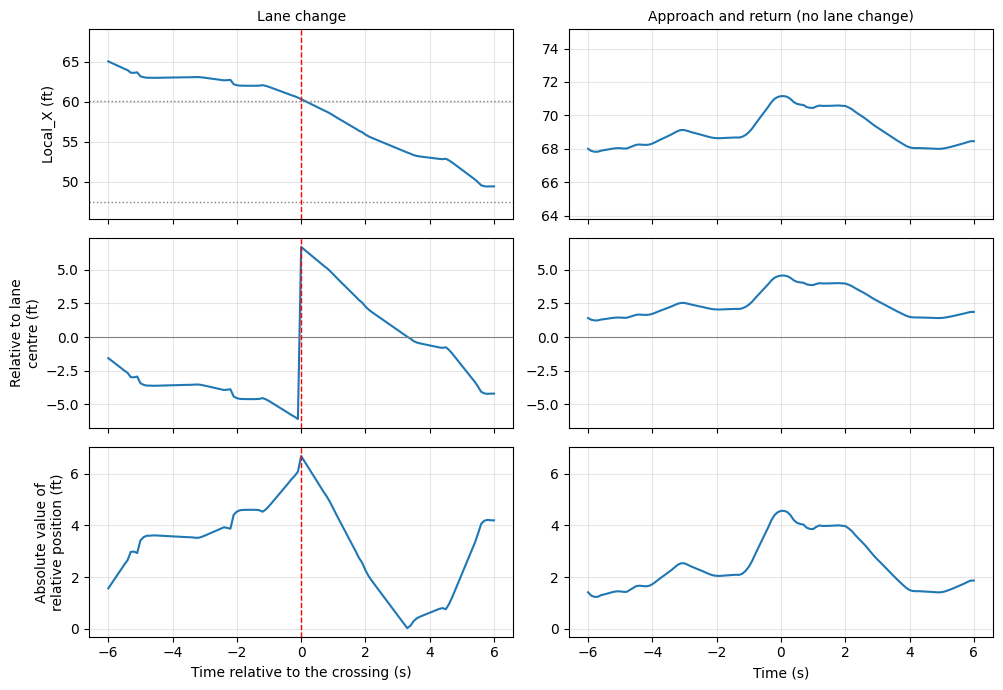

In [25]:
# Centre of each lane: median of Local_X over all the frames in that lane
centro = df[df["Lane_ID"].between(1, 6)].groupby("Lane_ID")["Local_X"].median()
confini = (centro.values[:-1] + centro.values[1:]) / 2     # boundaries between adjacent lanes
print("Centri delle corsie (ft):", centro.round(1).values)
print("Confini tra corsie (ft):", confini.round(1))

# Position relative to the centre of the lane the vehicle is currently in
df["x_rel"] = df["Local_X"] - df["Lane_ID"].map(centro)

MEZZA = 60                                    # 6 s before and after
t = np.arange(-MEZZA, MEZZA + 1) / 10
per_veicolo = {vid: v.set_index("Frame_ID") for vid, v in df.groupby("Vehicle_ID")}

def tratto(vid, f0):
    """Trajectory of vehicle vid within 6 s of frame f0, or None if it is incomplete."""
    v = per_veicolo[vid].loc[f0 - MEZZA : f0 + MEZZA]
    return v if len(v) == 2 * MEZZA + 1 else None

# 1) A clean lane change with 6 complete seconds on both sides and no other lane change
for _, e in cambi_puliti.sample(frac=1, random_state=3).iterrows():
    v = tratto(e["Vehicle_ID"], e["Frame_ID"])
    if v is not None and v["lane_change"].sum() == 1 and v["Lane_ID"].between(1, 6).all():
        cambio = v
        print("Cambio corsia: veicolo", e["Vehicle_ID"], "frame", e["Frame_ID"])
        break

# 2) An approach to the lane boundary followed by a return: at least 4.5 ft from the
#    lane centre, no lane change, start and end close to the centre
cand = df[df["Lane_ID"].between(1, 6) & (df["x_rel"].abs() > 4.5)]
for _, r in cand.sample(frac=1, random_state=3).iterrows():
    v = tratto(r["Vehicle_ID"], r["Frame_ID"])
    if v is None or v["lane_change"].any() or not v["Lane_ID"].between(1, 6).all():
        continue
    x = v["x_rel"].values
    if abs(x[0]) < 2 and abs(x[-1]) < 2:
        rientro = v
        print("Rientro: veicolo", r["Vehicle_ID"], "frame", r["Frame_ID"])
        break

# Figure: 3 rows (absolute, relative with sign, relative in absolute value) x 2 columns
fig, axes = plt.subplots(3, 2, figsize=(10, 7), sharex=True)
casi = [(cambio, "Lane change"), (rientro, "Approach and return (no lane change)")]
for col, (v, titolo) in enumerate(casi):
    x_abs, x_rel = v["Local_X"].values, v["x_rel"].values
    ax = axes[0, col]
    ax.plot(t, x_abs, color="tab:blue")
    lo, hi = x_abs.min() - 4, x_abs.max() + 4
    for c in confini:                         # lane boundaries visible in the plotted range
        if lo < c < hi:
            ax.axhline(c, color="gray", ls=":", lw=1)
    ax.set_ylim(lo, hi)
    ax.set_title(titolo, fontsize=10)
    axes[1, col].plot(t, x_rel, color="tab:blue")
    axes[1, col].axhline(0, color="gray", lw=0.8)
    axes[2, col].plot(t, np.abs(x_rel), color="tab:blue")
    for r in range(3):
        axes[r, col].grid(alpha=0.3)
        if col == 0:
            axes[r, col].axvline(0, color="red", ls="--", lw=1)   # crossing instant

for r in (1, 2):                              # same vertical scale in the two columns
    lims = [axes[r, c].get_ylim() for c in range(2)]
    for c in range(2):
        axes[r, c].set_ylim(min(l[0] for l in lims), max(l[1] for l in lims))

axes[0, 0].set_ylabel("Local_X (ft)")
axes[1, 0].set_ylabel("Relative to lane\ncentre (ft)")
axes[2, 0].set_ylabel("Absolute value of\nrelative position (ft)")
axes[2, 0].set_xlabel("Time relative to the crossing (s)")
axes[2, 1].set_xlabel("Time (s)")
plt.tight_layout()
plt.savefig("fig_relpos.pdf", bbox_inches="tight")
plt.show()